In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import (
    train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score
)
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
import numpy as np

from preprocessing import(
    my_preprocessor,
    my_tokenizer,
)
from helpfuncties import load_dataset

In [2]:
df = load_dataset()
X = df["Omschrijving"]
y = df["Product"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [4]:
tfidf = TfidfVectorizer(
    preprocessor=my_preprocessor,
    tokenizer=my_tokenizer,
    analyzer="word",
    token_pattern=None,
    ngram_range=(1, 2),
    sublinear_tf=True,
    norm="l2"
)

In [5]:
sgd_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("model", SGDClassifier(
    max_iter=5000,
    n_jobs=-1,
    warm_start=True,
    random_state=42,
    average=True
))
])

In [6]:
sgd_params = {
    # TF-IDF tuning
    "tfidf__max_features": [20000, 30000, 50000, None],
    "tfidf__min_df": [1, 2, 3, 5],
    "tfidf__max_df": [0.75, 0.85, 0.95],
    "tfidf__ngram_range": [(1,1), (1,2), (1,3)],

    # SGD tuning
    "model__loss": ["hinge", "log_loss", "modified_huber"],
    "model__alpha": stats.loguniform(1e-8, 1e-2),
    "model__penalty": ["l2"],
    "model__class_weight": ["balanced", None],
}

In [7]:
sgd_random = RandomizedSearchCV(
    estimator=sgd_pipeline,
    param_distributions=sgd_params,
    n_iter=50,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

sgd_random.fit(X_train, y_train)
best_random = sgd_random.best_params_

print("Beste parameters Random Search:", best_random)

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Beste parameters Random Search: {'model__alpha': np.float64(1.160068983900714e-05), 'model__class_weight': 'balanced', 'model__loss': 'log_loss', 'model__penalty': 'l2', 'tfidf__max_df': 0.75, 'tfidf__max_features': 20000, 'tfidf__min_df': 3, 'tfidf__ngram_range': (1, 2)}


In [8]:
grid_params = {
"model__alpha": [
    best_random["model__alpha"] * 0.1,
    best_random["model__alpha"] * 0.5,
    best_random["model__alpha"],
    best_random["model__alpha"] * 2,
    best_random["model__alpha"] * 5
]
}
sgd_grid = GridSearchCV(
    estimator=sgd_pipeline,
    param_grid=grid_params,
    scoring="f1_weighted",
    cv=3,
    verbose=1,
    n_jobs=-1
)

sgd_grid.fit(X_train, y_train)
sgd_best = sgd_grid.best_estimator_

Fitting 3 folds for each of 5 candidates, totalling 15 fits


In [9]:
cv_scores = cross_val_score(
    sgd_best, X_train, y_train, cv=5, scoring="f1_weighted"
)

print("CV F1-score:", cv_scores.mean())
print("Scores per fold:", cv_scores)

CV F1-score: 0.8606993145134503
Scores per fold: [0.86105644 0.86137996 0.85646287 0.85917292 0.86542438]


In [10]:
y_pred = sgd_best.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"Accuracy Testset: {acc:.3f}")
print(f"F1-score Testset: {f1:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Testset: 0.860
F1-score Testset: 0.857

Classification Report:
                    precision    recall  f1-score   support

      Bankrekening       0.88      0.84      0.86       447
Consumentenkrediet       0.84      0.55      0.66       284
        Creditcard       0.83      0.82      0.83       565
         Hypotheek       0.90      0.96      0.93       994
           Incasso       0.84      0.89      0.86      1229
Kredietregistratie       0.85      0.85      0.85       948

          accuracy                           0.86      4467
         macro avg       0.86      0.82      0.83      4467
      weighted avg       0.86      0.86      0.86      4467



[[ 377    3   30   15   12   10]
 [   6  156   18   22   54   28]
 [  23    2  465   13   45   17]
 [  11    3    5  951    9   15]
 [   7   12   19   32 1088   71]
 [   5   10   25   20   84  804]]


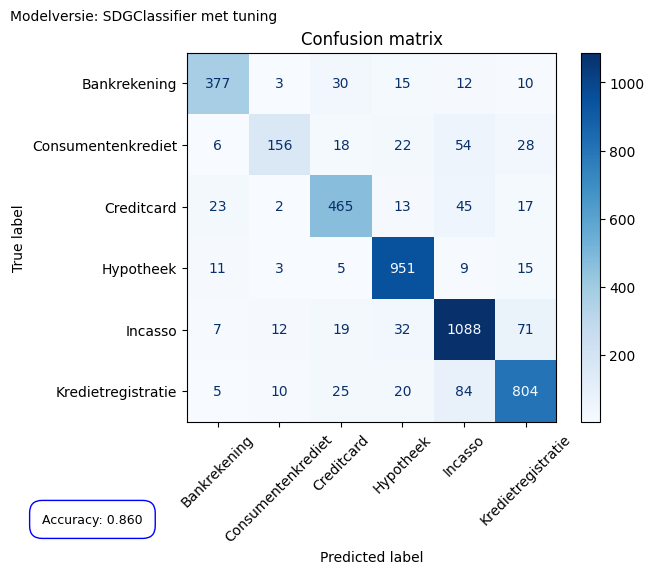

In [11]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: SDGClassifier met tuning", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {acc:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_SDG_met_tuning.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()